In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
from matplotlib.lines import Line2D
from matplotlib.offsetbox import OffsetImage, AnnotationBbox  
from rdkit import Chem
from rdkit.Chem import Draw, AllChem
from io import BytesIO
import os

生成分子结构图片...
  C10H14O No.1: OK
  C10H14O No.2: OK
  C10H14O No.3: OK
  C19H18O8 No.1: OK
  C19H18O8 No.2: OK
  C19H18O8 No.3: OK
  C7H8O2 No.1: OK
  C7H8O2 No.2: OK
  C7H8O2 No.3: OK
  C7H8O2 No.4: OK
  C7H8O2 No.5: OK
  C24H32O6 No.1: OK
  C24H32O6 No.2: OK
  C24H32O6 No.3: OK
  C24H32O6 No.4: OK
  C24H32O6 No.5: OK
  C21H30O5 No.1: OK
  C21H30O5 No.2: OK
  C21H30O5 No.3: OK

带结构式的 FPGNN 对比哑铃图已保存：dataset/isomer_fpgnn_with_structures.svg


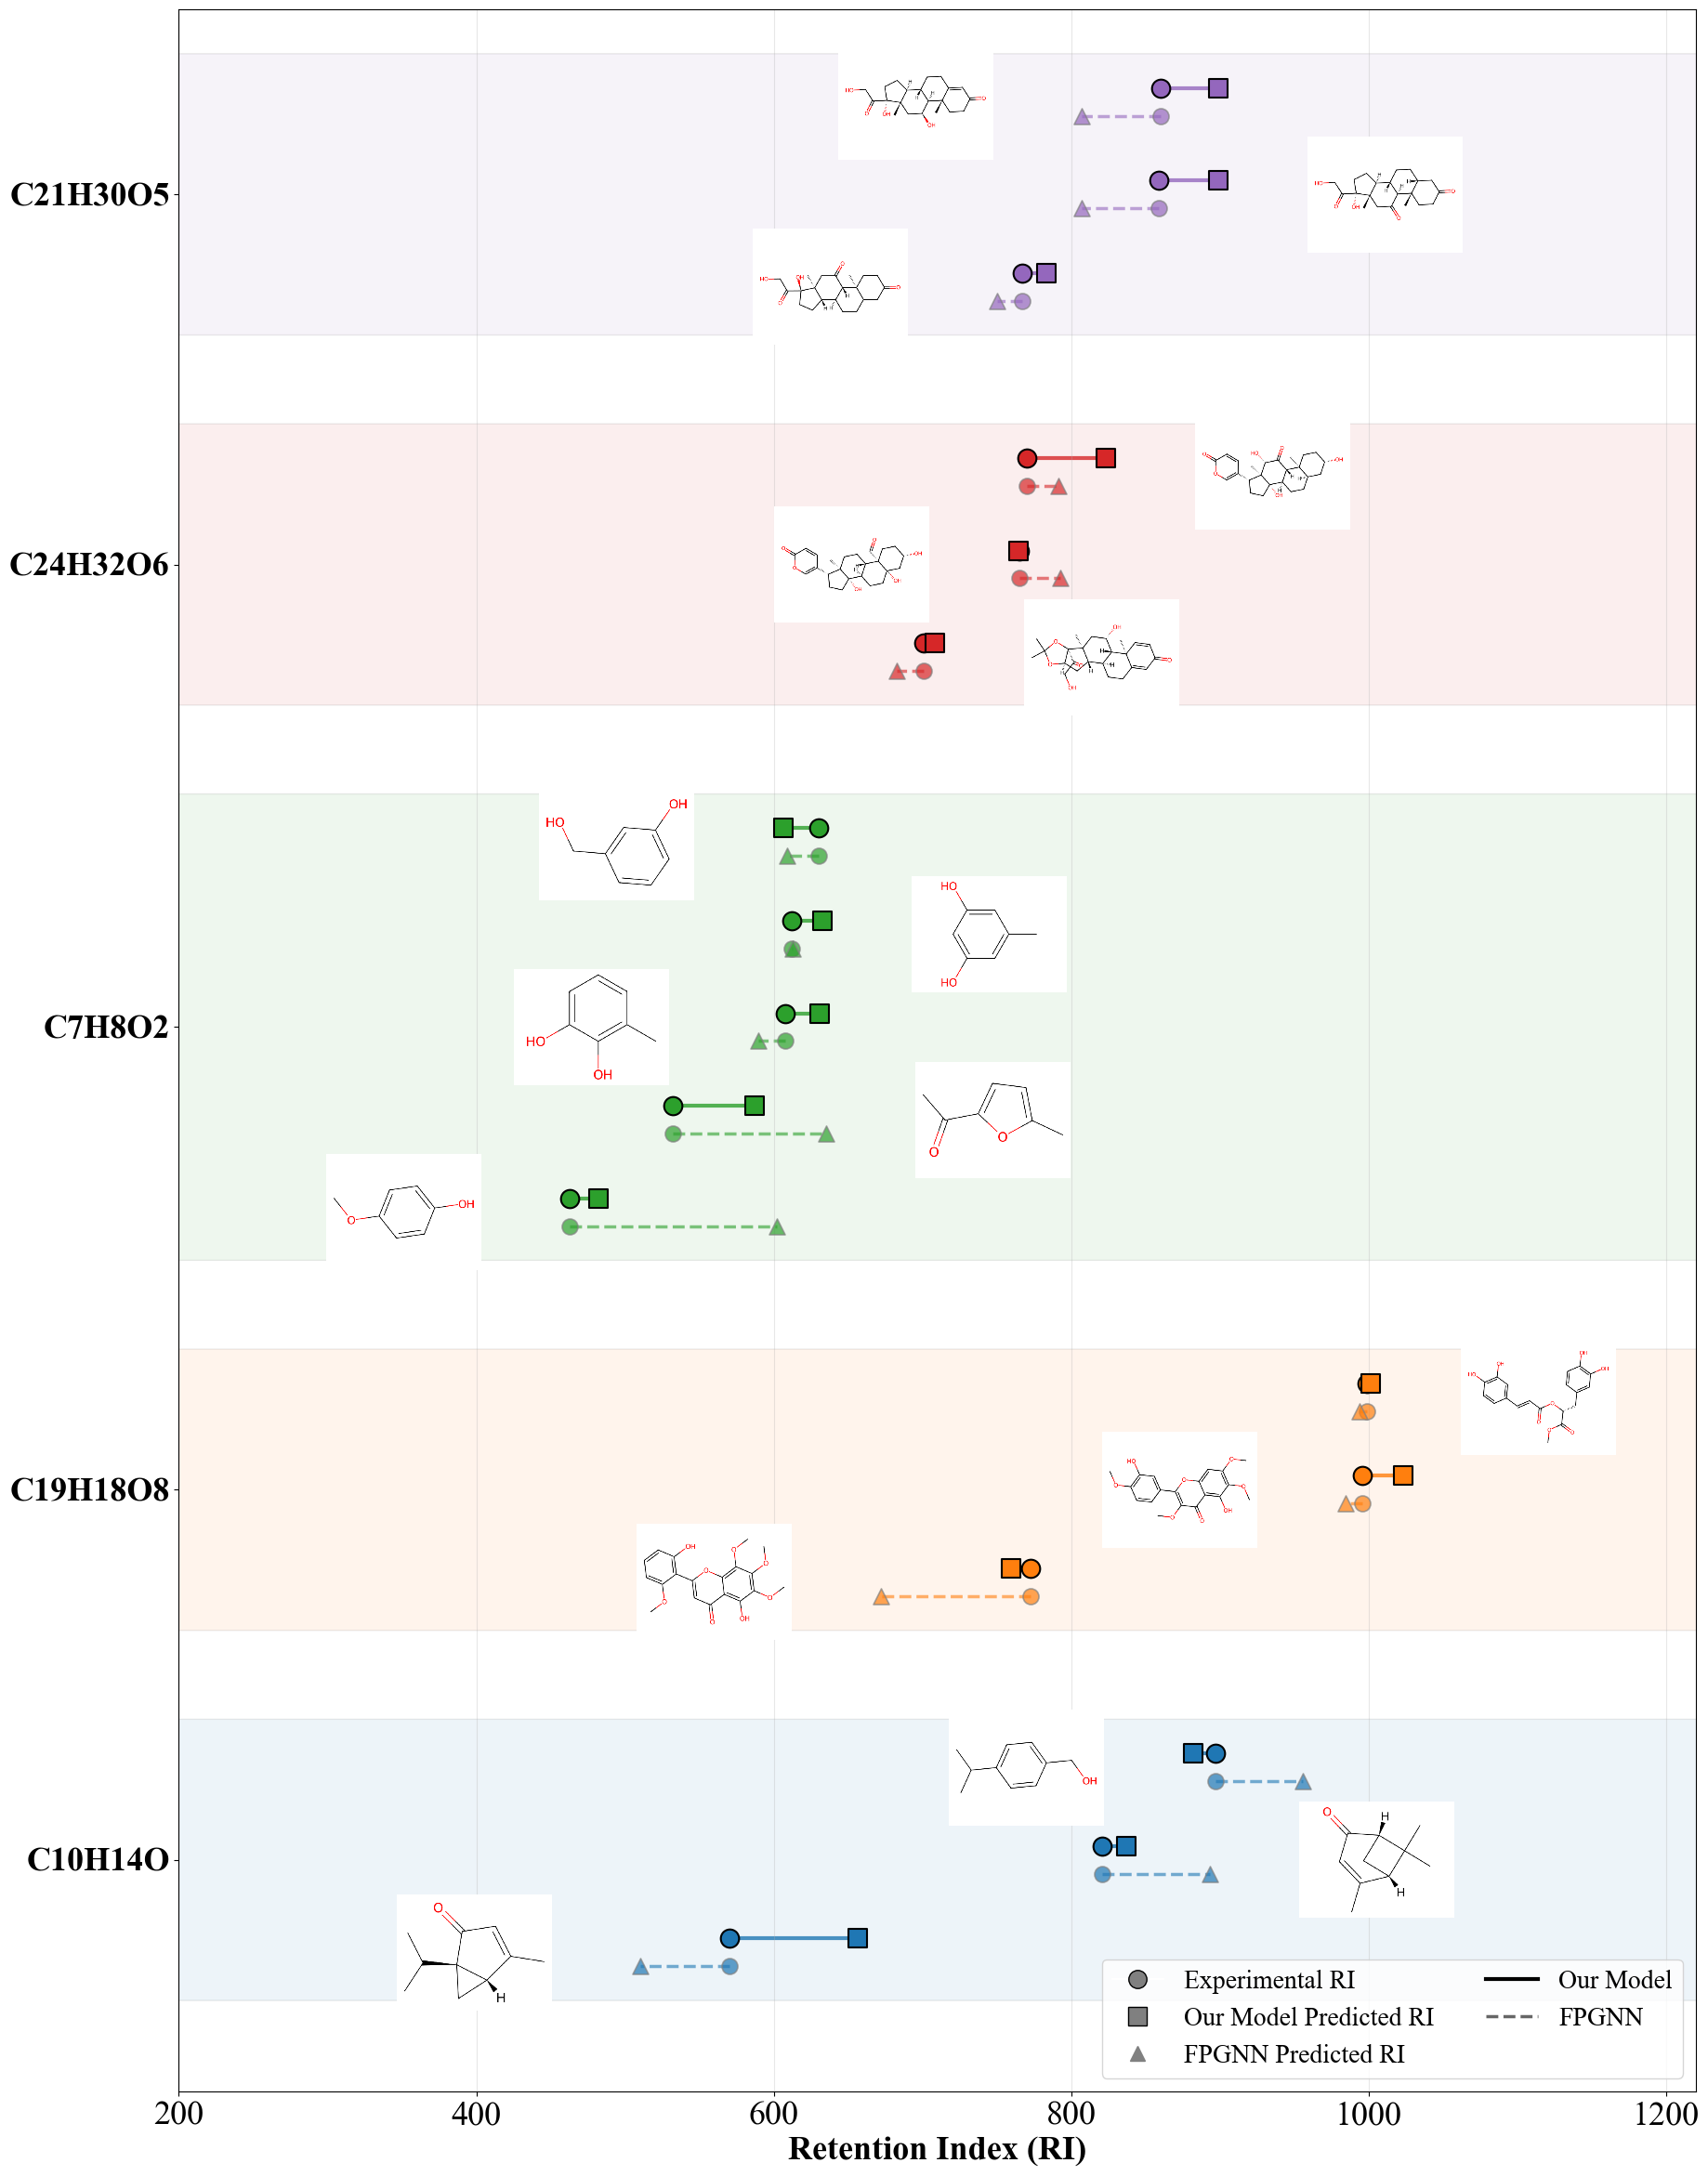

In [2]:

plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.size'] = 26

# 同分异构体数据（包含 SMILES）
data = [
    # C10H14O 组 (RI: 570, 821, 897)
    ('C10H14O', 1, 570.0, 656.31, 'CC1=CC(=O)[C@@]2([C@H]1C2)C(C)C'),
    ('C10H14O', 2, 821.0, 836.84, 'CC1=CC(=O)[C@H]2C[C@@H]1C2(C)C'),
    ('C10H14O', 3, 897.0, 882.09, 'CC(C)C1=CC=C(C=C1)CO'),
    # C19H18O8 组 (RI: 773, 996, 999)
    ('C19H18O8', 1, 773.0, 759.56, 'COC1=CC=CC(=C1C2=CC(=O)C3=C(C(=C(C(=C3O2)OC)OC)OC)O)O'),
    ('C19H18O8', 2, 996.0, 1023.29, 'COC1=C(C=C(C=C1)C2=C(C(=O)C3=C(C(=C(C=C3O2)OC)OC)O)OC)O'),
    ('C19H18O8', 3, 999.0, 1001.72, 'COC(=O)[C@@H](CC1=CC(=C(C=C1)O)O)OC(=O)/C=C/C2=CC(=C(C=C2)O)O'),
    # C7H8O2 组 (RI: 463, 532, 608, 612, 630)
    ('C7H8O2', 1, 463.0, 482.26, 'COC1=CC=C(C=C1)O'),
    ('C7H8O2', 2, 532.0, 586.88, 'CC1=CC=C(O1)C(=O)C'),
    ('C7H8O2', 3, 608.0, 631.13, 'OC1=CC=CC(C)=C1O'),
    ('C7H8O2', 4, 612.0, 632.51, 'CC1=CC(=CC(=C1)O)O'),
    ('C7H8O2', 5, 630.0, 606.43, 'C1=CC(=CC(=C1)O)CO'),
    # C24H32O6 组 (RI: 677, 701, 753, 765, 770)
    ('C24H32O6', 1, 677.0, 708.25, 'C[C@@]12[C@](C(COC(C)=O)=O)(O)CC[C@@]1([H])[C@]3([H])C[C@H](C)C4=CC(C=C[C@]4(C)[C@@]3([H])[C@@H](O)C2)=O'),
    ('C24H32O6', 2, 701.0, 708.25, 'C[C@@]12[C@@]3(C(CO)=O)[C@@](OC(C)(O3)C)([H])C[C@@]1([H])[C@]4([H])CCC5=CC(C=C[C@]5(C)[C@@]4([H])[C@@H](O)C2)=O'),
    ('C24H32O6', 3, 753.0, 737.77, 'C[C@]([C@@H](C(C=C1)=COC1=O)[C@H]2O)(CC[C@@]3([H])[C@@]4([H])CC[C@@]5(O)[C@@]3(CC[C@H](O)C5)C)[C@@]64[C@@H]2O6'),
    ('C24H32O6', 4, 765.0, 764.65, 'O=C[C@@]12[C@]3([H])[C@](CC[C@@]1(C[C@@H](O)CC2)O)([H])[C@@]4([C@@](C)([C@@H](C(C=C5)=COC5=O)CC4)CC3)O'),
    ('C24H32O6', 5, 770.0, 823.40, 'C[C@@]12[C@@]([C@@]3([H])[C@]([C@@]4([C@](C[C@H](CC4)O)([H])CC3)C)([H])C([C@H]1O)=O)(CC[C@]2([H])C(C=C5)=COC5=O)O'),
    # C21H30O5 组 (RI: 767, 859, 860)
    ('C21H30O5', 1, 767.0, 783.47, 'C[C@@]12[C@](CC[C@]2(O)C(CO)=O)([H])[C@@]3([H])[C@@](C(C1)=O)([H])[C@@]4(C(CC(CC4)=O)([H])CC3)C'),
    ('C21H30O5', 2, 859.0, 898.74, 'C[C@]12CCC(=O)C[C@H]1CC[C@@H]3[C@@H]2C(=O)C[C@]4([C@H]3CC[C@@]4(C(=O)CO)O)C'),
    ('C21H30O5', 3, 860.0, 898.74, 'C[C@]12CCC(=O)C=C1CC[C@@H]3[C@@H]2[C@H](C[C@]4([C@H]3CC[C@@]4(C(=O)CO)O)C)O'),
]

# 读取 FPGNN 预测结果
fpgnn_df = pd.read_csv('/Users/wangxujie/PycharmProjects/Mole/test_prediction_fpgnn.txt', sep='\t')
fpgnn_df.columns = ['Smiles', 'Correct', 'Predict']
fpgnn_df['Correct'] = fpgnn_df['Correct'].apply(lambda x: float(str(x).strip('[] ')))
fpgnn_df['Predict'] = fpgnn_df['Predict'].apply(lambda x: float(str(x).strip('[] ')))

df = pd.DataFrame(data, columns=['Formula', 'No', 'Exp_RI', 'Pred_RI', 'SMILES'])

# 通过 Exp_RI 匹配 FPGNN 预测结果
fpgnn_preds = []
for _, row in df.iterrows():
    exp_ri = row['Exp_RI']
    matches = fpgnn_df[fpgnn_df['Correct'] == exp_ri]
    if len(matches) > 0:
        fpgnn_preds.append(matches.iloc[0]['Predict'])
    else:
        matches = fpgnn_df[(fpgnn_df['Correct'] - exp_ri).abs() <= 1.0]
        if len(matches) > 0:
            fpgnn_preds.append(matches.iloc[0]['Predict'])
        else:
            fpgnn_preds.append(np.nan)

df['FPGNN_Pred'] = fpgnn_preds

# 用 RDKit 生成分子结构图片
def smiles_to_image(smiles, size=(400, 300)):
    """将 SMILES 转换为分子结构图片"""
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            return None
        AllChem.Compute2DCoords(mol)
        img = Draw.MolToImage(mol, size=size)
        return img
    except Exception as e:
        print(f"Error processing {smiles}: {e}")
        return None

# 生成所有分子结构图片
print("生成分子结构图片...")
structure_images = {}
for idx, row in df.iterrows():
    img = smiles_to_image(row['SMILES'])
    if img is not None:
        structure_images[(row['Formula'], row['No'])] = img
        print(f"  {row['Formula']} No.{row['No']}: OK")
    else:
        print(f"  {row['Formula']} No.{row['No']}: FAILED")

# 创建对比哑铃图（宽度压缩到 4/5）
fig, ax = plt.subplots(figsize=(19, 24))

y_pos = 0
y_ticks = []
y_labels = []
group_positions = []
all_ri_values = []

formulas = ['C10H14O', 'C19H18O8', 'C7H8O2', 'C24H32O6', 'C21H30O5']
custom_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
color_map = dict(zip(formulas, custom_colors))

# 全局计数器，用于交替左右放置
global_idx = 0
# 获取所有数据行（按顺序）
all_rows = df.values.tolist()  # 或者直接用 df.iterrows() 但需要知道总数
total_molecules = len(df)

# 按原始规则生成方向列表：索引0（第1个）放左，1放右，2放左，3放右...
directions = ['left' if i % 2 == 0 else 'right' for i in range(total_molecules)]

# 强制第14个（索引13）放左边
directions[3] = 'left'

for formula in formulas:
    group = df[df['Formula'] == formula].dropna(subset=['FPGNN_Pred']).sort_values('Exp_RI')
    if len(group) < 2:
        continue
    n = len(group)
    group_positions.append((y_pos, y_pos + n - 1, formula))

    group_vals = group[['Exp_RI', 'Pred_RI', 'FPGNN_Pred']].values.flatten()
    group_range = group_vals.max() - group_vals.min()

    for idx, (_, row) in enumerate(group.iterrows()):
        exp = row['Exp_RI']
        pred = row['Pred_RI']
        fpgnn = row['FPGNN_Pred']
        color = color_map[formula]
        all_ri_values.extend([exp, pred, fpgnn])

        # 我们的模型：实线连接（放大）
        ax.plot([exp, pred], [y_pos + 0.15, y_pos + 0.15], color=color, linewidth=3, alpha=0.8, zorder=1)
        ax.scatter(exp, y_pos + 0.15, color=color, s=200, zorder=3, edgecolors='black', linewidth=1.5)
        ax.scatter(pred, y_pos + 0.15, color=color, s=200, marker='s', zorder=3, edgecolors='black', linewidth=1.5)

        # FPGNN：虚线连接（在下方，放大）
        ax.plot([exp, fpgnn], [y_pos - 0.15, y_pos - 0.15], color=color, linewidth=2.5, linestyle='--', alpha=0.6, zorder=1)
        ax.scatter(exp, y_pos - 0.15, color=color, s=150, zorder=3, edgecolors='gray', linewidth=1.2, alpha=0.7)
        ax.scatter(fpgnn, y_pos - 0.15, color=color, s=150, marker='^', zorder=3, edgecolors='gray', linewidth=1.2, alpha=0.7)

        # ------------------- 修改开始 -------------------
        # 使用 OffsetImage + AnnotationBbox 放置结构式，可独立控制大小
        key = (row['Formula'], row['No'])
        if key in structure_images:
            img = structure_images[key]
            img_array = np.array(img)
            # 创建图像对象，zoom 控制放大倍数（可调整，例如 1.8）
            imagebox = OffsetImage(img_array, zoom=0.3)
            # 计算锚点位置：左右交替放置，偏移量 80 个 RI 单位避免与数据点重叠
            min_ri = min(exp, pred, fpgnn)
            max_ri = max(exp, pred, fpgnn)
            offset = 60
            # 根据预先计算的方向列表决定当前放置位置
            direction = directions[global_idx]   # 直接取索引

            if direction == 'left':
                anchor_x = min_ri - offset
                box_alignment = (1, 0.5)   # 图像右边缘对准锚点，向左延伸
            else:  # 'right'
                anchor_x = max_ri + offset
                box_alignment = (0, 0.5)   # 图像左边缘对准锚点，向右延伸

            # 创建注解框并添加到轴
            ab = AnnotationBbox(imagebox, (anchor_x, y_pos),
                                xycoords='data', boxcoords="data",
                                box_alignment=box_alignment,
                                frameon=False)
            ax.add_artist(ab)
        # ------------------- 修改结束 -------------------

        global_idx += 1
        y_pos += 1

    y_pos += 1.0

# y轴标签
for start, end, formula in group_positions:
    mid = (start + end) / 2
    y_ticks.append(mid)
    y_labels.append(formula)
    rect = FancyBboxPatch((0, start - 0.5), 1, end - start + 1.0,
                          boxstyle="round,pad=0.02", facecolor=color_map[formula],
                          alpha=0.08, transform=ax.get_yaxis_transform(),
                          clip_on=True, zorder=0)
    ax.add_patch(rect)

ax.set_xlim(200, 1220)

ax.set_yticks(y_ticks)
ax.set_yticklabels(y_labels, fontsize=26, fontweight='bold')
ax.set_xlabel('Retention Index (RI)', fontsize=26, fontweight='bold')
ax.tick_params(labelsize=26)
ax.grid(True, alpha=0.3, axis='x')

# 图例
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', markersize=14,
           markeredgecolor='black', label='Experimental RI'),
    Line2D([0], [0], marker='s', color='w', markerfacecolor='gray', markersize=14,
           markeredgecolor='black', label='Our Model Predicted RI'),
    Line2D([0], [0], marker='^', color='w', markerfacecolor='gray', markersize=12,
           markeredgecolor='gray', label='FPGNN Predicted RI'),
    Line2D([0], [0], color='black', linewidth=3, label='Our Model'),
    Line2D([0], [0], color='black', linewidth=2.5, linestyle='--', alpha=0.6, label='FPGNN'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=20, ncol=2)

ax.set_ylim(-1.5, y_pos-1)
plt.tight_layout()

save_dir = 'dataset'
os.makedirs(save_dir, exist_ok=True)
plt.savefig(os.path.join(save_dir, 'isomer_fpgnn_with_structures.svg'), bbox_inches='tight')
plt.savefig('dataset/isomer_fpgnn_with_structures.svg', bbox_inches='tight')
print("\n带结构式的 FPGNN 对比哑铃图已保存：dataset/isomer_fpgnn_with_structures.svg")